In [2]:
import numpy as np
import pandas as pd
from scipy.spatial import distance
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
%matplotlib inline

In [3]:
df = pd.read_csv('cluster_validation_data.txt', sep=",", header=None)
df.head()

,0,1
0,2.510076,2.159303
1,3.739776,0.974175
2,-0.142930,2.960866
3,2.817929,2.268013
4,2.302407,2.119619


In [4]:
# normalize data
X = df.values
sc = StandardScaler()
sc.fit(X)
X = sc.transform(X)



In [5]:
import random
import math


def kmeans(X,k=3,max_iterations=100):
    '''
    X: multidimensional data
    k: number of clusters
    max_iterations: number of repetitions before clusters are established
    
    Steps:
    1. Convert data to numpy aray
    2. Pick indices of k random point without replacement
    3. Find class (P) of each data point using euclidean distance
    4. Stop when max_iteration are reached of P matrix doesn't change
    
    Return:
    np.array: containg class of each data point
    '''
    """
    IMPLEMENT THE CODE FOR K Means Implementaion From Scratch
    
    
    """

    centroids = []
    
    for centroidNo in range(k):
        p1 = random.randint(0, len(X)-1)
        c1 = (df[0][p1], df[1][p1])
        centroids.append(c1)

    #print(centroids)

    for iteration in range(0, max_iterations):
        divisionInClusters = {}
        
        for cNo in range(k):
            divisionInClusters[cNo+1] = []
            cNo += 1
    
        #print(divisionInClusters)

        for pointNo in range(0, len(X)):
            if( not (df[0][pointNo], df[1][pointNo]) in centroids):
                #d1 is the distance of that point in the iteration from the centroid 1  
                lengths = []
                for clusterNo in range(k):
                    lengths.append(math.ceil(abs(df[0][pointNo] - centroids[clusterNo][0]) + abs(df[1][pointNo] - centroids[clusterNo][1])))
                
                #print(lengths)
                
                minI = 0
                minV = lengths[0]
                
                for thisPoint in range(k):
                    if(lengths[thisPoint] < minV):
                        minV = lengths[thisPoint]
                        minI = thisPoint
            
                divisionInClusters[minI+1].append([df[0][pointNo], df[1][pointNo]])
                
        #print(divisionInClusters)
        
        newCentroids = []

        for clusterNumber in range(k):
            xOfNewCentroid = 0
            yOfNewCentroid = 0

            sumX = 0
            sumY = 0
            
            for thisP in range(len(divisionInClusters[clusterNumber+1])):
                sumX = sumX + divisionInClusters[clusterNumber+1][thisP][0]
                sumY = sumY + divisionInClusters[clusterNumber+1][thisP][1]

            xOfNewCentroid = math.ceil(sumX/(len(divisionInClusters[clusterNumber+1])))
            yOfNewCentroid = math.ceil(sumY/(len(divisionInClusters[clusterNumber+1])))
            
            newCentroids.append((xOfNewCentroid, yOfNewCentroid))
        
        same = True

        for count in range(k):
            if(centroids[count] != newCentroids[count]):
                same = False

        #print(same)

        if(same == True):
            print("THIS IS THE POINT OF CONVERGENCE")
            print("ITERATION: ", iteration)
            break
            
        centroids = newCentroids
        
        #print(newCentroids)


    print("\nCLUSTER 1 COUNT: ", len(divisionInClusters[1]))
    print("\nCLUSTER 2 COUNT: ", len(divisionInClusters[2]))
    print("\nCLUSTER 3 COUNT: ", len(divisionInClusters[3]), "\n")

    #print(divisionInClusters)

    values = []
    clusters = []
    for i in divisionInClusters.keys():
        for j in divisionInClusters[i]:
            values.append(j)
            clusters.append(i)

    P = pd.DataFrame({'Point': values, 'Cluster': clusters})
    #print(P)
    return P

    
P = kmeans(X)




THIS IS THE POINT OF CONVERGENCE
ITERATION:  2

CLUSTER 1 COUNT:  201

CLUSTER 2 COUNT:  214

CLUSTER 3 COUNT:  185 



In [6]:
assert len(df) == len(P)


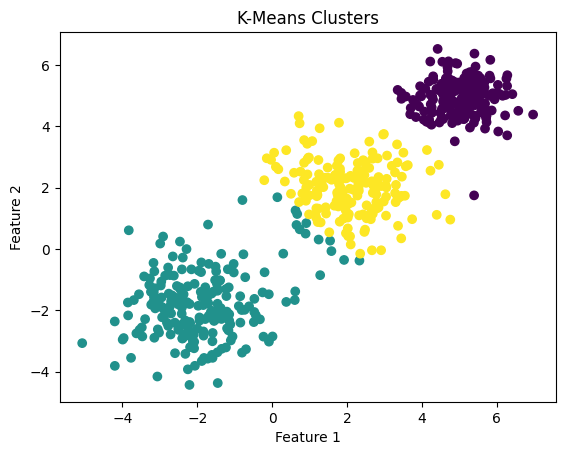

In [7]:

import matplotlib.pyplot as plt

def visualize_kmeans_clusters(P):
    """
    Visualizes the clusters formed by the k-means algorithm.
    
    Args:
      P (pandas.DataFrame): A DataFrame containing 'Point' (features) and 'Cluster' columns.
    """
    
    # Extract features and cluster labels
    features = P['Point'].tolist()
    clusters = P['Cluster'].tolist()
    
    # Separate features into x and y components (assuming 2D data)
    x = [point[0] for point in features]
    y = [point[1] for point in features]
    
    # Create a scatter plot with different colors for each cluster
    plt.scatter(x, y, c=clusters)
    
    # Add labels and title
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('K-Means Clusters')
    
    plt.show()

visualize_kmeans_clusters(P)

ValueError: 'c' argument must be a color, a sequence of colors, or a sequence of numbers, not                                     Point  Cluster
0     [5.3947654105129, 1.74986977032754]        1
1     [4.8791812033706, 3.51356612668269]        1
2       [5.19067038309555, 5.26063957788]        1
3    [5.34951372871151, 5.77351169881178]        1
4    [3.95127506765868, 5.01238317684737]        1
..                                    ...      ...
595  [2.44295392675276, 2.56363874168865]        3
596  [1.80104845849219, 1.89392855630205]        3
597  [2.59310764987127, 2.64621072707107]        3
598  [4.13549593023625, 3.22973999245438]        3
599  [1.52667781833885, 0.54534149031259]        3

[600 rows x 2 columns]

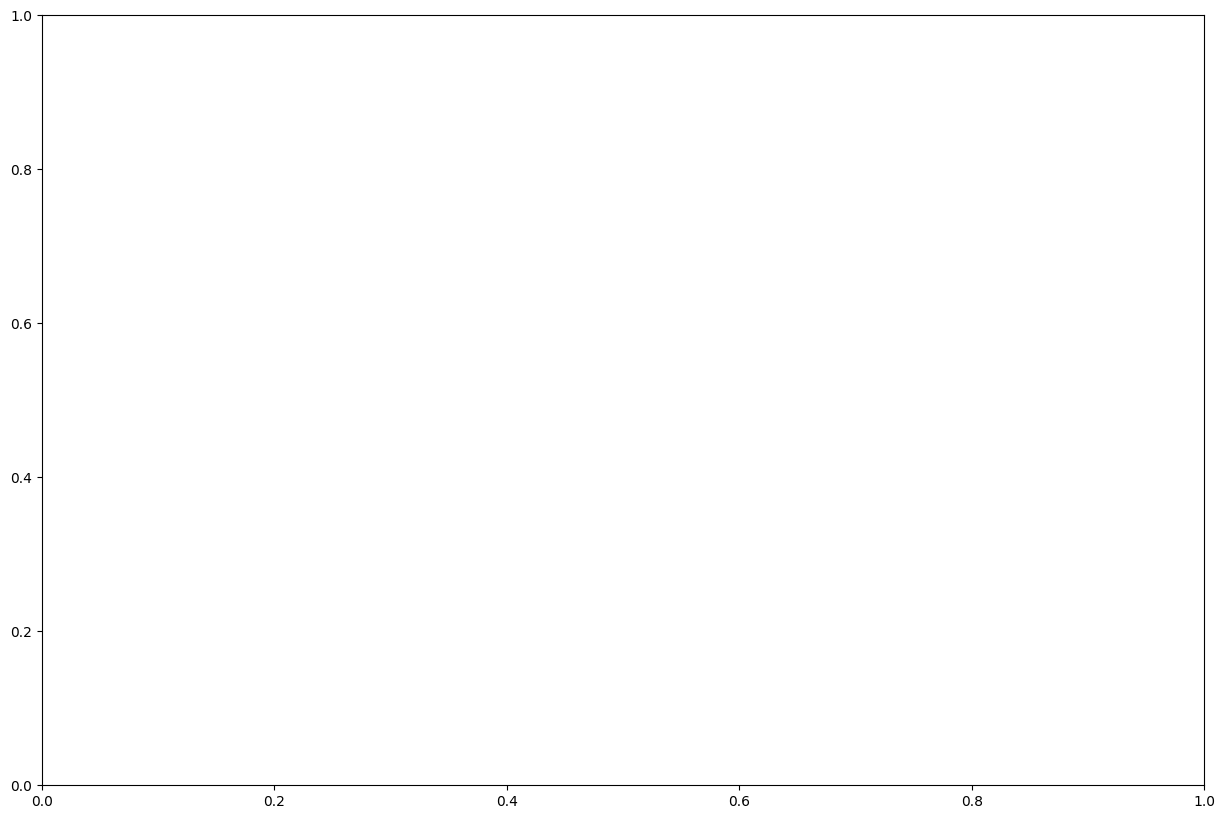

In [8]:
# denormalize data
X = sc.inverse_transform(X)
plt.figure(figsize=(15,10))
plt.scatter(X[:,0],X[:,1],c=P)
plt.show()